# Import Libraries

In [1]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# LogisticRegressionSGD class Implementation

In [2]:
class LogisticRegressionSGD:
    def __init__(self, learning_rate=0.01, iterations=100):
        self.lr = learning_rate
        self.iterations = iterations
        self.weights = None
        self.bias = 0
        self.cost_history = []

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

    def cost(self, y_pred, y_true):
        return -np.mean(y_true * np.log(y_pred + 1e-8) + (1 - y_true) * np.log(1 - y_pred + 1e-8))

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)

        # Stochastic Gradient Descent: update after each sample
        for epoch in range(self.iterations):
            epoch_cost = 0

            for i in range(n_samples):
                xi = X[i:i + 1]
                yi = y[i:i + 1]

                # Forward pass for single sample
                linear_model = np.dot(xi, self.weights) + self.bias
                y_pred = self.sigmoid(linear_model)

                # Compute gradients for single sample
                dw = np.dot(xi.T, (y_pred - yi))
                db = np.sum(y_pred - yi)

                # Update parameters immediately
                self.weights -= self.lr * dw.flatten()
                self.bias -= self.lr * db

                epoch_cost += self.cost(y_pred, yi)

            self.cost_history.append(epoch_cost / n_samples)

    def predict(self, X):
        return (self.sigmoid(np.dot(X, self.weights) + self.bias) >= 0.5).astype(int)

# LogisticRegressionBatchGD class Implementation

In [3]:
class LogisticRegressionBatchGD:
    def __init__(self, learning_rate=0.01, iterations=100):
        self.lr = learning_rate
        self.iterations = iterations
        self.weights = None
        self.bias = 0
        self.cost_history = []

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

    def cost(self, y_pred, y_true):
        return -np.mean(y_true * np.log(y_pred + 1e-8) + (1 - y_true) * np.log(1 - y_pred + 1e-8))

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)

        # Batch Gradient Descent: update using entire dataset
        for i in range(self.iterations):
            linear_model = np.dot(X, self.weights) + self.bias
            y_pred = self.sigmoid(linear_model)

            dw = (1 / n_samples) * np.dot(X.T, (y_pred - y))
            db = (1 / n_samples) * np.sum(y_pred - y)

            self.weights -= self.lr * dw
            self.bias -= self.lr * db

            self.cost_history.append(self.cost(y_pred, y))

    def predict(self, X):
        return (self.sigmoid(np.dot(X, self.weights) + self.bias) >= 0.5).astype(int)

# Prepare Data

In [4]:
np.random.seed(42)
X = np.random.randn(200, 2) * 10
y = (np.dot(X, np.array([3, -2])) + 1 > 0).astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train Both Models

In [5]:
sgd_model = LogisticRegressionSGD(learning_rate=0.01, iterations=100)
sgd_model.fit(X_train, y_train)

batch_model = LogisticRegressionBatchGD(learning_rate=0.01, iterations=100)
batch_model.fit(X_train, y_train)

# Evaluate the Models

In [6]:
sgd_pred = sgd_model.predict(X_test)
batch_pred = batch_model.predict(X_test)

print(f"SGD Accuracy: {np.mean(sgd_pred == y_test):.2f}")
print(f"Batch GD Accuracy: {np.mean(batch_pred == y_test):.2f}")

SGD Accuracy: 0.97
Batch GD Accuracy: 0.97


# Visualize Cost Function Convergence

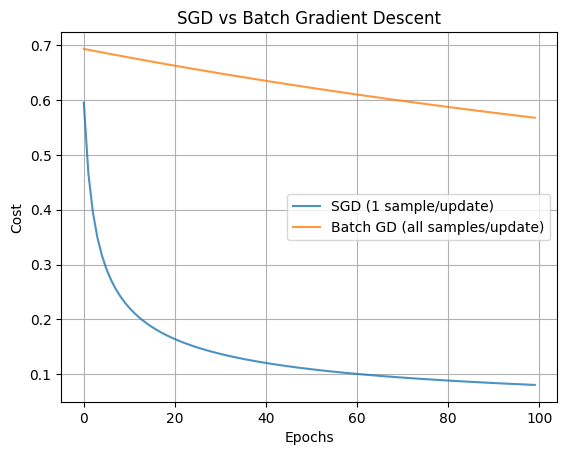

In [7]:
plt.plot(sgd_model.cost_history, label='SGD (1 sample/update)', alpha=0.8)
plt.plot(batch_model.cost_history, label='Batch GD (all samples/update)', alpha=0.8)
plt.title('SGD vs Batch Gradient Descent')
plt.xlabel('Epochs')
plt.ylabel('Cost')
plt.legend()
plt.grid(True)
plt.show()